# 📊 Customer Churn Prediction
### Telecom Customer Analysis using Logistic Regression

**Author:** Kshirsagar Mahesh S.  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

---

## 🎯 Problem Statement
A telecom company wants to identify customers who are likely to cancel their subscription (churn).  
By predicting churn early, the company can take proactive retention actions and reduce revenue loss.

## 📌 Project Workflow
1. Load & Understand the Data
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Model Building (Logistic Regression)
5. Model Evaluation
6. Key Insights & Business Recommendations

---
## Step 1 — Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve
)

# Settings
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


---
## Step 2 — Load & Understand the Data

In [2]:
# Load dataset
df = pd.read_csv('telecom_churn.csv')

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (1000, 17)

First 5 rows:


,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0001,Male,0,No,No,35,Yes,No,No,No internet service,No internet service,One year,Yes,Electronic check,21.64,795.70,No
1,CUST0002,Female,0,Yes,No,51,Yes,Yes,Fiber optic,No,No,Month-to-month,Yes,Electronic check,78.99,4009.23,No
2,CUST0003,Male,0,Yes,No,37,Yes,Yes,DSL,No,Yes,Month-to-month,No,Mailed check,72.52,2702.44,No
3,CUST0004,Male,0,Yes,No,57,Yes,Yes,Fiber optic,No,Yes,Month-to-month,No,Electronic check,95.13,5447.70,Yes
4,CUST0005,Male,0,Yes,Yes,8,Yes,Yes,Fiber optic,No,No,One year,No,Credit card (automatic),99.36,760.03,No


In [3]:
# Basic info
print('Dataset Info:')
print('-' * 40)
df.info()

Dataset Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        1000 non-null   object 
 1   Gender            1000 non-null   object 
 2   SeniorCitizen     1000 non-null   int64  
 3   Partner           1000 non-null   object 
 4   Dependents        1000 non-null   object 
 5   Tenure            1000 non-null   int64  
 6   PhoneService      1000 non-null   object 
 7   MultipleLines     1000 non-null   object 
 8   InternetService   1000 non-null   object 
 9   OnlineSecurity    1000 non-null   object 
 10  TechSupport       1000 non-null   object 
 11  Contract          1000 non-null   object 
 12  PaperlessBilling  1000 non-null   object 
 13  PaymentMethod     1000 non-null   object 
 14  MonthlyCharges    1000 non-null   float64
 15  TotalCharges      1000 non-null   f

In [4]:
# Statistical summary
print('Statistical Summary:')
df.describe().round(2)

Statistical Summary:


,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
count,1000.00,1000.00,1000.00,1000.00
mean,0.17,35.97,65.58,2353.87
std,0.37,20.30,26.52,1705.51
min,0.00,1.00,18.02,14.26
25%,0.00,18.00,47.34,920.54
50%,0.00,36.00,69.80,1908.80
75%,0.00,54.00,87.58,3561.97
max,1.00,71.00,109.98,7590.94


In [5]:
# Check missing values
missing = df.isnull().sum()
print('Missing Values:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found ✅')

Missing Values:
No missing values found ✅


In [6]:
# Check churn distribution
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('Churn Distribution:')
print('-' * 30)
for label in ['Yes', 'No']:
    print(f"  {label}: {churn_counts[label]} customers ({churn_pct[label]:.1f}%)")

Churn Distribution:
------------------------------
  Yes: 239 customers (23.9%)
  No: 761 customers (76.1%)


---
## Step 3 — Exploratory Data Analysis (EDA)

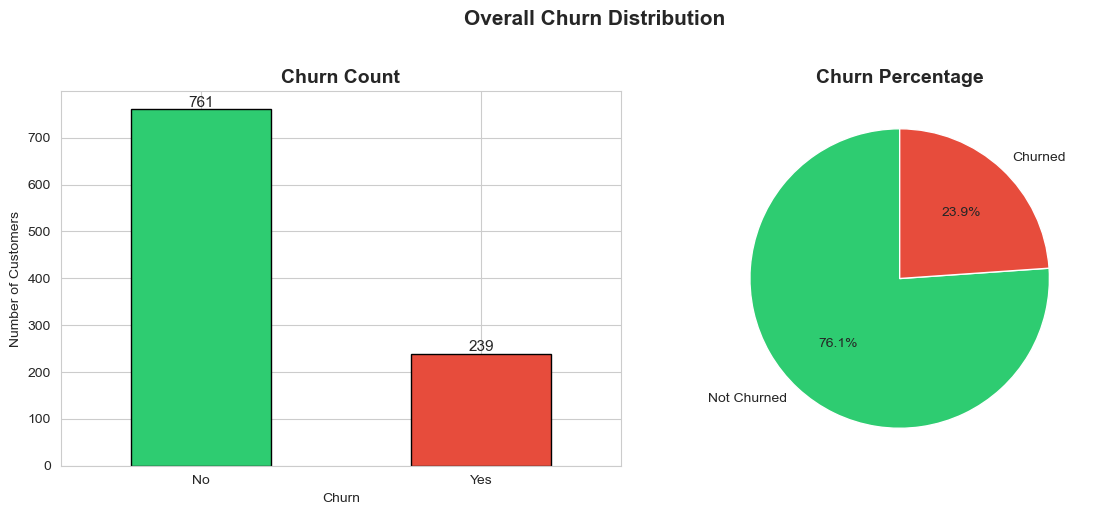

Observation: ~24% of customers churned — this is the target variable we want to predict.


In [7]:
# --- Plot 1: Churn Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
colors = ['#2ecc71', '#e74c3c']
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', rot=0)
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for p in axes[0].patches:
    axes[0].annotate(str(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height() + 5),
                     ha='center', fontsize=11)

# Pie chart
df['Churn'].value_counts().plot(kind='pie', ax=axes[1], colors=colors,
                                 autopct='%1.1f%%', startangle=90,
                                 labels=['Not Churned', 'Churned'])
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Overall Churn Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot1_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: ~24% of customers churned — this is the target variable we want to predict.')

<Figure size 1000x500 with 0 Axes>

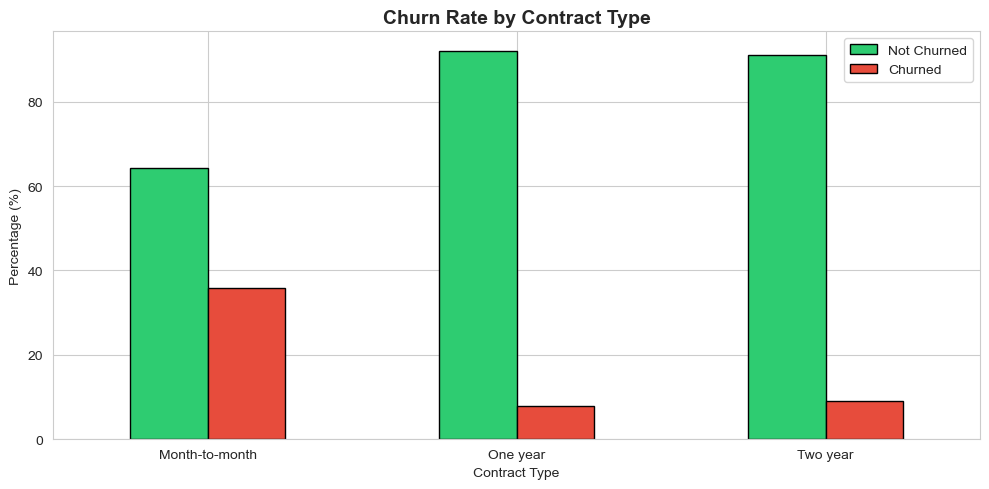

Observation: Month-to-month customers have the highest churn rate — key risk segment.


In [8]:
# --- Plot 2: Churn by Contract Type ---
plt.figure(figsize=(10, 5))
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
contract_churn_pct = contract_churn.div(contract_churn.sum(axis=1), axis=0) * 100

contract_churn_pct.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black', rot=0)
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Percentage (%)')
plt.legend(['Not Churned', 'Churned'])
plt.tight_layout()
plt.savefig('plot2_contract_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Month-to-month customers have the highest churn rate — key risk segment.')

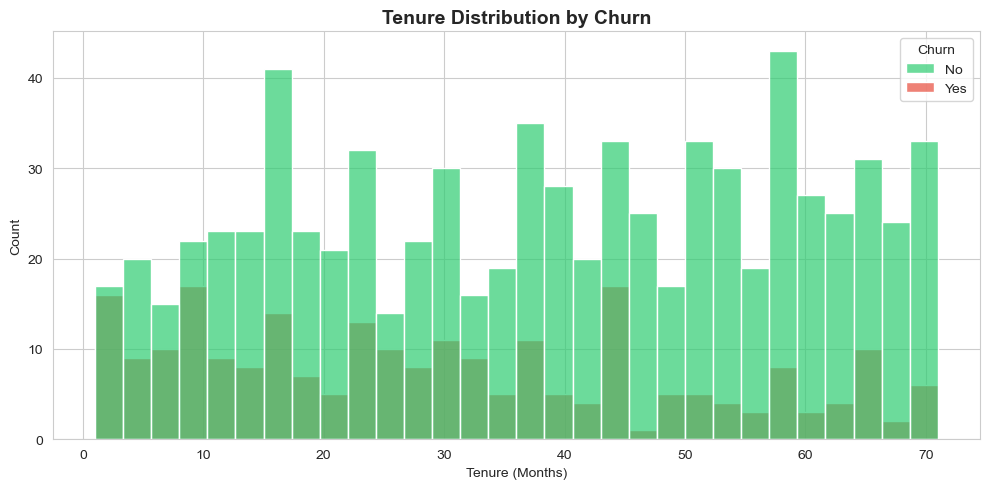

Observation: Customers with short tenure (< 12 months) churn significantly more.


In [9]:
# --- Plot 3: Tenure vs Churn ---
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Tenure', hue='Churn', bins=30,
             palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, alpha=0.7)
plt.title('Tenure Distribution by Churn', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot3_tenure_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Customers with short tenure (< 12 months) churn significantly more.')

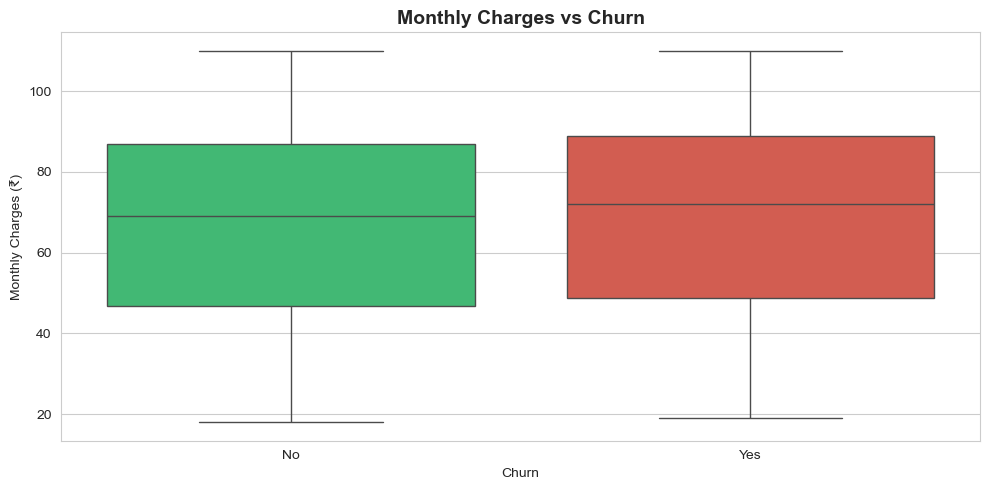

Observation: Churned customers tend to have higher monthly charges.


In [10]:
# --- Plot 4: Monthly Charges vs Churn ---
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette={'Yes': '#e74c3c', 'No': '#2ecc71'})
plt.title('Monthly Charges vs Churn', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges (₹)')
plt.tight_layout()
plt.savefig('plot4_charges_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Churned customers tend to have higher monthly charges.')

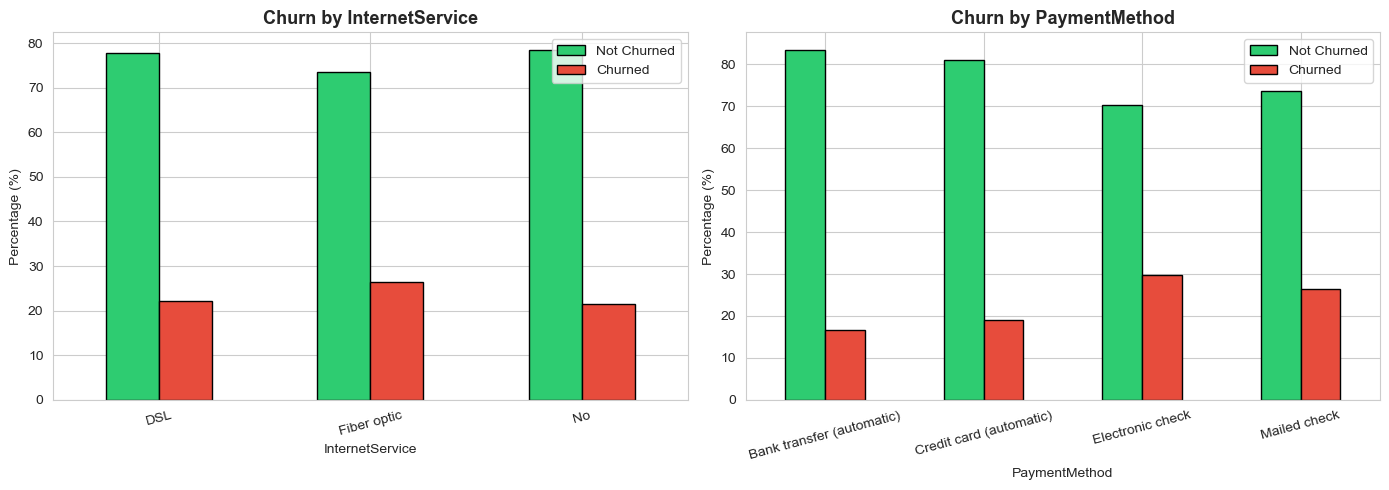

Observation: Fiber optic users and electronic check payers have highest churn rates.


In [11]:
# --- Plot 5: Churn by Internet Service & Payment Method ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['InternetService', 'PaymentMethod']):
    grp = df.groupby([col, 'Churn']).size().unstack(fill_value=0)
    grp_pct = grp.div(grp.sum(axis=1), axis=0) * 100
    grp_pct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black', rot=15)
    ax.set_title(f'Churn by {col}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.legend(['Not Churned', 'Churned'])

plt.tight_layout()
plt.savefig('plot5_service_payment_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Fiber optic users and electronic check payers have highest churn rates.')

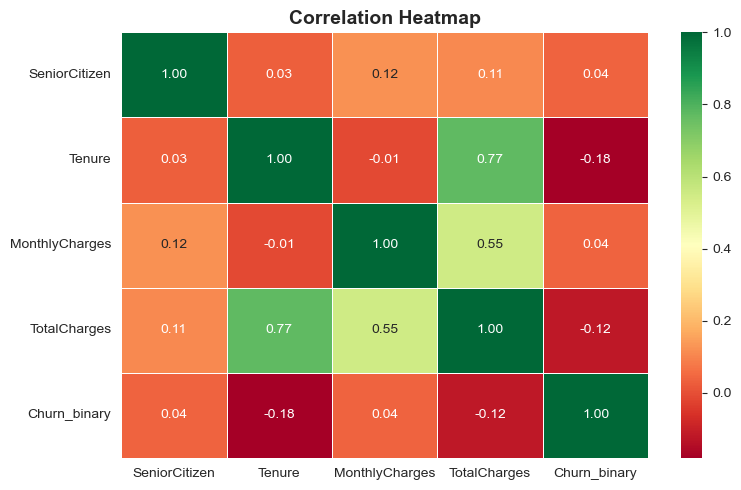

Observation: Tenure has a negative correlation with churn — longer customers stay more.


In [12]:
# --- Plot 6: Correlation Heatmap (numeric only) ---
plt.figure(figsize=(8, 5))
numeric_cols = df[['SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_cols['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

sns.heatmap(numeric_cols.corr().round(2), annot=True, cmap='RdYlGn',
            linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Tenure has a negative correlation with churn — longer customers stay more.')

---
## Step 4 — Data Preprocessing

Before building the model, we need to:
- Drop irrelevant columns (CustomerID)
- Encode categorical variables (convert text to numbers)
- Scale numerical features
- Split data into train and test sets

In [13]:
# Make a copy to preserve original
df_model = df.copy()

# Drop CustomerID — not useful for prediction
df_model.drop('CustomerID', axis=1, inplace=True)

# Encode target variable: Yes=1, No=0
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

print('Target encoding done: Yes=1, No=0')
print('Churn value counts:\n', df_model['Churn'].value_counts())

Target encoding done: Yes=1, No=0
Churn value counts:
 Churn
0    761
1    239
Name: count, dtype: int64


In [14]:
# Identify categorical columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print('Categorical columns to encode:', cat_cols)

# Apply Label Encoding
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    
print('\nLabel Encoding completed ✅')
df_model.head(3)

Categorical columns to encode: ['Gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'TechSupport', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Label Encoding completed ✅


,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,0,0,35,1,0,2,1,1,1,1,2,21.64,795.70,0
1,0,0,1,0,51,1,2,1,0,0,0,1,2,78.99,4009.23,0
2,1,0,1,0,37,1,2,0,0,2,0,0,3,72.52,2702.44,0


In [15]:
# Define features (X) and target (y)
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('\nFeature columns:', X.columns.tolist())

Features shape: (1000, 15)
Target shape: (1000,)

Feature columns: ['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'TechSupport', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [16]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size :', X_train.shape[0], 'rows')
print('Testing set size  :', X_test.shape[0], 'rows')
print('\nTrain churn rate  :', round(y_train.mean()*100, 1), '%')
print('Test churn rate   :', round(y_test.mean()*100, 1), '%')

Training set size : 800 rows
Testing set size  : 200 rows

Train churn rate  : 23.9 %
Test churn rate   : 24.0 %


In [17]:
# Feature Scaling (StandardScaler)
# Important for Logistic Regression — brings all features to same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # only transform test, never fit

print('Feature scaling done ✅')
print('Mean of first feature (should be ~0):', round(X_train_scaled[:, 0].mean(), 4))

Feature scaling done ✅
Mean of first feature (should be ~0): 0.0


---
## Step 5 — Model Building: Logistic Regression

In [18]:
# Build and train the model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print('Model trained successfully ✅')

# Predictions
y_pred       = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # probability of churn

print('Predictions made on test set ✅')

Model trained successfully ✅
Predictions made on test set ✅


---
## Step 6 — Model Evaluation

In [19]:
# Core metrics
acc     = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print('=' * 40)
print('       MODEL PERFORMANCE SUMMARY')
print('=' * 40)
print(f'  Accuracy    : {acc*100:.2f}%')
print(f'  ROC-AUC     : {roc_auc:.4f}')
print('=' * 40)
print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))

       MODEL PERFORMANCE SUMMARY
  Accuracy    : 76.00%
  ROC-AUC     : 0.7718

Detailed Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.77      0.97      0.86       152
     Churned       0.50      0.10      0.17        48

    accuracy                           0.76       200
   macro avg       0.64      0.54      0.52       200
weighted avg       0.71      0.76      0.69       200



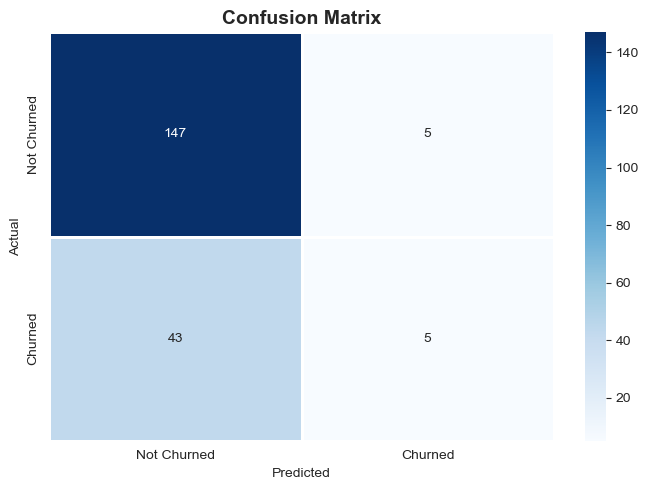

True Positives  (correctly predicted churn)     : 5
True Negatives  (correctly predicted no churn)  : 147
False Positives (predicted churn, but stayed)   : 5
False Negatives (missed churners)               : 43


In [20]:
# --- Plot 7: Confusion Matrix ---
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            linewidths=1)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('plot7_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (correctly predicted churn)     : {tp}')
print(f'True Negatives  (correctly predicted no churn)  : {tn}')
print(f'False Positives (predicted churn, but stayed)   : {fp}')
print(f'False Negatives (missed churners)               : {fn}')

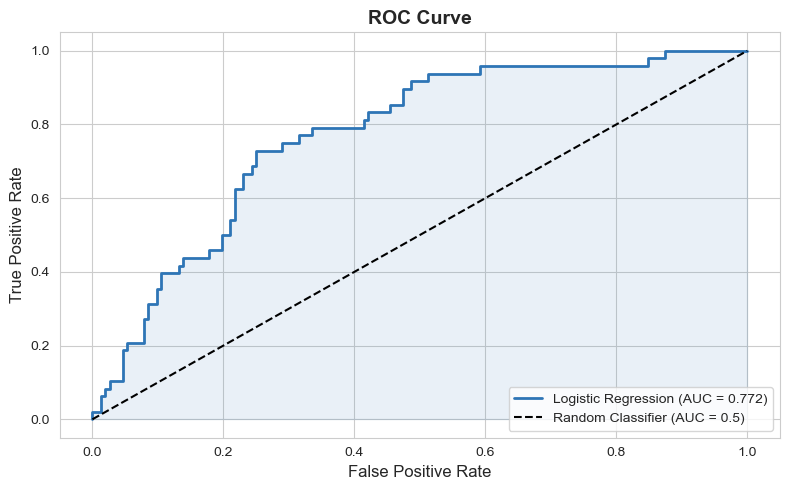

AUC = 0.772 — A value above 0.80 indicates a strong model.


In [21]:
# --- Plot 8: ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='#2E75B6', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='#2E75B6')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plot8_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC = {roc_auc:.3f} — A value above 0.80 indicates a strong model.')

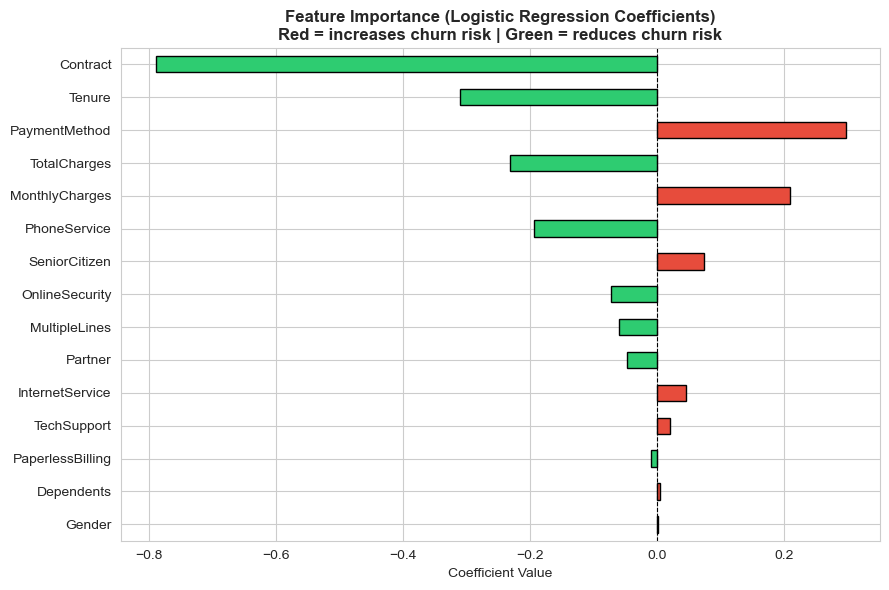

Features with large positive values INCREASE churn probability.
Features with large negative values REDUCE churn probability.


In [22]:
# --- Plot 9: Feature Importance (Logistic Regression Coefficients) ---
coefficients = pd.Series(model.coef_[0], index=X.columns)
coefficients_sorted = coefficients.abs().sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors_bar = ['#e74c3c' if c > 0 else '#2ecc71'
              for c in coefficients[coefficients_sorted.index]]
coefficients[coefficients_sorted.index].plot(kind='barh', color=colors_bar, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Importance (Logistic Regression Coefficients)\nRed = increases churn risk | Green = reduces churn risk',
          fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('plot9_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Features with large positive values INCREASE churn probability.')
print('Features with large negative values REDUCE churn probability.')

---
## Step 7 — Key Insights & Business Recommendations

In [23]:
print("""
========================================================
         KEY INSIGHTS FROM THE ANALYSIS
========================================================

📌 1. CONTRACT TYPE is the strongest churn predictor.
   → Month-to-month customers churn at much higher rates.
   → Recommendation: Offer discounts to convert them to annual plans.

📌 2. SHORT TENURE customers (< 12 months) are high risk.
   → New customers need early engagement to build loyalty.
   → Recommendation: Onboarding rewards for the first 6 months.

📌 3. FIBER OPTIC users churn more than DSL users.
   → Possibly due to higher charges or unmet expectations.
   → Recommendation: Investigate service quality feedback.

📌 4. ELECTRONIC CHECK payment method has higher churn.
   → Customers on automatic payment (credit card/bank)
     are significantly less likely to churn.
   → Recommendation: Incentivize switching to auto-pay.

📌 5. HIGH MONTHLY CHARGES increase churn risk.
   → Customers paying above average are more price-sensitive.
   → Recommendation: Loyalty discounts for high-value customers.

========================================================
         MODEL SUMMARY
========================================================
  Algorithm    : Logistic Regression
  Dataset Size : 1,000 customers
  Features Used: 15
  Train/Test   : 80% / 20%
========================================================
""")


         KEY INSIGHTS FROM THE ANALYSIS

📌 1. CONTRACT TYPE is the strongest churn predictor.
   → Month-to-month customers churn at much higher rates.
   → Recommendation: Offer discounts to convert them to annual plans.

📌 2. SHORT TENURE customers (< 12 months) are high risk.
   → New customers need early engagement to build loyalty.
   → Recommendation: Onboarding rewards for the first 6 months.

📌 3. FIBER OPTIC users churn more than DSL users.
   → Possibly due to higher charges or unmet expectations.
   → Recommendation: Investigate service quality feedback.

📌 4. ELECTRONIC CHECK payment method has higher churn.
   → Customers on automatic payment (credit card/bank)
     are significantly less likely to churn.
   → Recommendation: Incentivize switching to auto-pay.

📌 5. HIGH MONTHLY CHARGES increase churn risk.
   → Customers paying above average are more price-sensitive.
   → Recommendation: Loyalty discounts for high-value customers.

         MODEL SUMMARY
  Algorithm    :

---
## ✅ Project Complete!

**What we did:**
- Loaded and explored a 1,000-customer telecom dataset
- Performed thorough EDA with 6 visualizations
- Preprocessed data (encoding, scaling, train-test split)
- Built a Logistic Regression model
- Evaluated using Accuracy, F1-Score, ROC-AUC, and Confusion Matrix
- Derived 5 actionable business recommendations

**Skills demonstrated:** Python • Pandas • NumPy • Matplotlib • Seaborn • Scikit-learn • EDA • Feature Engineering • Model Evaluation